In [57]:
import os
import sys
import glob
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from igraph import Graph
import celloracle as co

In [51]:
%matplotlib inline

In [285]:
# visualization settings
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300

In [2]:
results_dir = "/cellar/users/aklie/projects/igvf/topic_grn_links/eval/results"
dataset_name = "meta_analysis"
in_date = "03Sep23"

# TF metadata

In [3]:
# Read in the metadata
tf_metadata_df = pd.read_csv(os.path.join(results_dir, dataset_name, in_date, "tf_metadata_topics_baselines.tsv"), sep="\t", index_col=0)
len(tf_metadata_df)

709

In [4]:
# Sort by presence in literature
tf_metadata_df = tf_metadata_df.sort_values(by="in_literature", ascending=False)
tf_metadata_df.head()

,in_scenic,in_aracne,in_celloracle,in_literature,number_grns,in_topics,in_igvf_b01_LeftCortex,in_Bridge_Satpathy,in_both,in_neither
Mef2a,True,True,True,True,93,True,True,True,True,False
Runx1,True,False,True,True,76,True,True,True,True,False
Mef2c,True,True,True,True,87,True,True,True,True,False
Stat3,True,True,True,True,43,True,True,True,True,False
Sall1,True,True,False,True,29,True,True,True,True,False


# TF network scores

In [5]:
# Read in the network scores
tf_scores_df = pd.read_csv(os.path.join(results_dir, dataset_name, in_date, "tf_only_network_scores.tsv"), sep="\t").rename(columns={"Unnamed: 0": "tf_name"})
tf_scores_df.head()

,tf_name,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,grn_name
0,Runx1t1,2,0.004866,0,0.000000,2,0.004866,0.0,0.005795,Bridge_Satpathy_aracne_balanced_genotype_micro...
1,Runx1t1,50,0.142045,2,0.005682,48,0.136364,81.0,0.226653,Bridge_Satpathy_aracne_balanced_genotype_micro...
2,Runx1t1,37,0.099196,1,0.002681,36,0.096515,24.0,0.183886,Bridge_Satpathy_aracne_balanced_genotype_micro...
3,Runx1t1,1,0.001031,1,0.001031,0,0.000000,0.0,0.014566,Bridge_Satpathy_celloracle_balanced_genotype_m...
4,Runx1t1,1,0.001211,1,0.001211,0,0.000000,0.0,0.015317,Bridge_Satpathy_celloracle_balanced_genotype_m...


In [6]:
# Check to make sure all the tfs in the scores are in the metadata
(~tf_scores_df.tf_name.isin(tf_metadata_df.index)).sum()

0

# GRN metadata

In [41]:
# Read in all the network metadata
grn_metadata_df = pd.read_csv(os.path.join(results_dir, dataset_name, in_date, "cleaned_grn_metadata.tsv"), sep="\t", index_col=0)
len(grn_metadata_df)

120

In [42]:
grn_metadata_df = grn_metadata_df[(grn_metadata_df["genotype"] != "both") & (grn_metadata_df["method"].isin(["celloracle", "grnboost2", "wgcna", "scenic"])) & (grn_metadata_df["normalization"] == "pf_log1p_pf") & (grn_metadata_df["dataset"] == "igvf_b01_LeftCortex")]
len(grn_metadata_df)

8

In [43]:
grn_metadata_df.head()

,dataset,method,cells,genes,normalization,genotype,scale_free_topology_score,mean_connectivity,median_connectivity,max_connectivity,number_tfs,filtered_links_path,degree_centrality_out_path,eigenvector_centrality_path,betweenness_centrality_path,ulm_path,viper_path,aucell_path
grn_name,,,,,,,,,,,,,,,,,,
igvf_b01_LeftCortex_celloracle_balanced_genotype_microglia_B6J_0.05_pf_log1p_pf,igvf_b01_LeftCortex,celloracle,balanced_genotype_microglia,0.05,pf_log1p_pf,B6J,0.889136,5.340454,3.0,57.0,182,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...
igvf_b01_LeftCortex_celloracle_balanced_genotype_microglia_CASTJ_0.05_pf_log1p_pf,igvf_b01_LeftCortex,celloracle,balanced_genotype_microglia,0.05,pf_log1p_pf,CASTJ,0.878897,5.563282,3.0,66.0,177,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...
igvf_b01_LeftCortex_grnboost2_balanced_genotype_microglia_B6J_0.05_pf_log1p_pf,igvf_b01_LeftCortex,grnboost2,balanced_genotype_microglia,0.05,pf_log1p_pf,B6J,0.814523,4.127967,2.0,155.0,363,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...
igvf_b01_LeftCortex_grnboost2_balanced_genotype_microglia_CASTJ_0.05_pf_log1p_pf,igvf_b01_LeftCortex,grnboost2,balanced_genotype_microglia,0.05,pf_log1p_pf,CASTJ,0.800005,3.493450,2.0,132.0,372,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...
igvf_b01_LeftCortex_scenic_balanced_genotype_microglia_B6J_0.05_pf_log1p_pf,igvf_b01_LeftCortex,scenic,balanced_genotype_microglia,0.05,pf_log1p_pf,B6J,0.891132,3.051106,1.0,71.0,120,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...


In [44]:
links_dict = {}
for i, (grn_name, row) in tqdm(enumerate(grn_metadata_df.iterrows()), total=len(grn_metadata_df)):
    links_df = pd.read_csv(row["filtered_links_path"], sep="\t")
    links_df["coef"] = links_df["weight_signed"]
    links_df["coef_abs"] = links_df["weight_unsigned"]
    links_dict[grn_name] = links_df

  0%|          | 0/8 [00:00<?, ?it/s]

In [45]:
# Make a celloracle links object
links = co.Links(name="balanced_genotype_microglia_comparison", links_dict=links_dict)

In [46]:
# Filter to top 2000 links
links.filter_links(weight="weight_unsigned", p=None, threshold_number=2000)

In [47]:
# Calculate network scores.
links.get_network_score()

In [48]:
# assign a color to each key in links_dict based on a seaborn palette
palette = sns.color_palette('Paired', len(links_dict))
links.palette = pd.DataFrame({'key': links_dict.keys(), 'palette': palette}).set_index('key')

In [49]:
# Save gene scores for each gene in the network
gene_scores = links.merged_score
gene_scores

,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,cluster
Rbpj,34,0.045455,3,0.004011,31,0.041444,111.0,6.930448e-01,igvf_b01_LeftCortex_celloracle_balanced_genoty...
Plxdc2,14,0.018717,14,0.018717,0,0.000000,0.0,5.890347e-01,igvf_b01_LeftCortex_celloracle_balanced_genoty...
Slc9a9,13,0.017380,13,0.017380,0,0.000000,0.0,2.963070e-01,igvf_b01_LeftCortex_celloracle_balanced_genoty...
Plcl1,15,0.020053,15,0.020053,0,0.000000,0.0,3.036634e-01,igvf_b01_LeftCortex_celloracle_balanced_genoty...
Rora,47,0.062834,2,0.002674,45,0.060160,346.0,8.383115e-01,igvf_b01_LeftCortex_celloracle_balanced_genoty...
...,...,...,...,...,...,...,...,...,...
Pot1b,1,0.000618,1,0.000618,0,0.000000,0.0,1.534577e-18,igvf_b01_LeftCortex_wgcna_balanced_genotype_mi...
Fgd2,1,0.000618,1,0.000618,0,0.000000,0.0,3.057371e-13,igvf_b01_LeftCortex_wgcna_balanced_genotype_mi...
Tbc1d9,1,0.000618,1,0.000618,0,0.000000,0.0,0.000000e+00,igvf_b01_LeftCortex_wgcna_balanced_genotype_mi...
Ppp1r21,1,0.000618,1,0.000618,0,0.000000,0.0,1.227661e-18,igvf_b01_LeftCortex_wgcna_balanced_genotype_mi...


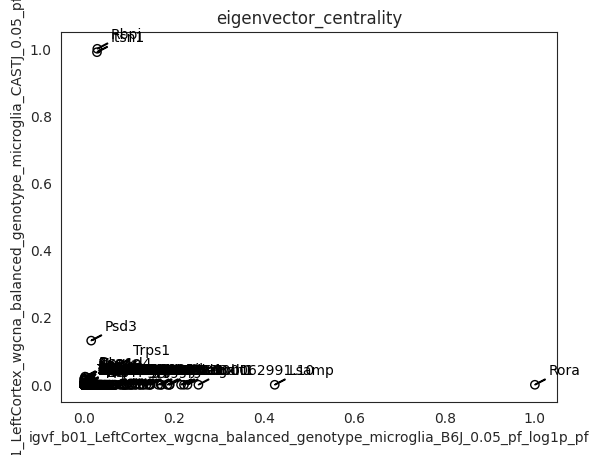

In [56]:
# Cross genotype, same algorithm
links.plot_score_comparison_2D(
    value="eigenvector_centrality",
    cluster1="igvf_b01_LeftCortex_wgcna_balanced_genotype_microglia_B6J_0.05_pf_log1p_pf", 
    cluster2="igvf_b01_LeftCortex_wgcna_balanced_genotype_microglia_CASTJ_0.05_pf_log1p_pf",
    percentile=98
)

In [137]:
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
import itertools

In [355]:
tfoi = "Foxn3"
genotype = "B6J"
plot_links = links.filtered_links[f"igvf_b01_LeftCortex_celloracle_balanced_genotype_microglia_{genotype}_0.05_pf_log1p_pf"]
plot_links = plot_links[(plot_links["source"] == tfoi) | (plot_links["target"] == tfoi)]
plot_links

,source,target,weight_signed,weight_unsigned,p,-logp,weight_minmax_normalized,description,coef,coef_abs
106,Foxn3,Srgap2,0.060054,0.060054,7.082483e-09,8.149814,0.360217,NaN,0.060054,0.060054
127,Foxn3,Apbb1ip,0.058295,0.058295,1.976423e-10,9.704120,0.349663,NaN,0.058295,0.058295
147,Foxn3,Tanc2,0.057296,0.057296,1.058986e-09,8.975110,0.343674,NaN,0.057296,0.057296
153,Foxn3,Inpp5d,0.056551,0.056551,9.786719e-08,7.009363,0.339201,NaN,0.056551,0.056551
178,Foxn3,Nrxn3,-0.055007,0.055007,4.360166e-09,8.360497,0.329944,NaN,-0.055007,0.055007
245,Foxn3,Cadm2,-0.051996,0.051996,3.994653e-12,11.398521,0.311881,NaN,-0.051996,0.051996
479,Foxn3,Slco2b1,0.047173,0.047173,9.831071e-07,6.007399,0.282951,NaN,0.047173,0.047173
484,Foxn3,Elmo1,0.047116,0.047116,9.276094e-09,8.032635,0.282610,NaN,0.047116,0.047116
486,Foxn3,Ssh2,0.047035,0.047035,2.168946e-07,6.663751,0.282125,NaN,0.047035,0.047035
671,Foxn3,Lrrc4c,-0.044442,0.044442,1.970147e-12,11.705501,0.266571,NaN,-0.044442,0.044442


In [356]:
def multilayered_graph(links, tfoi):
    """Create a multilayered graph of the network around a TF of interest.

    Using a links dataframe, create a multilayered graph of the network around a TF of interest.
    The first layer is the nodes with edges going into the TF of interest.
    The second layer is the TF of interest.
    The third layer is the nodes with edges going out of the TF of interest.
    """
    edges = plot_links[["source", "target", "weight_signed"]].values
    G = nx.Graph()

    # Add nodes to the graph
    G.add_node(tfoi, layer=2)
    for edge in edges:
        if edge[1] == tfoi:
            G.add_node(edge[0], layer=1)
        elif edge[0] == tfoi:
            G.add_node(edge[1], layer=3)
    

    # Add edges to the graph
    G.add_weighted_edges_from(edges)
    return G

In [357]:
G = multilayered_graph(plot_links, tfoi)
pos = nx.multipartite_layout(G, subset_key="layer")
edge_list = [(u, v) for u, v in G.edges()]
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]

In [358]:
plt.rcParams["pdf.fonttype"] = 42

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 45 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'F', 'I', 'K', 'L', 'M', 'N', 'P', 'S', 'T', 'U', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'five', 'four', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'space', 't', 'three', 'two', 'x', 'y']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 20, 21, 22, 23, 24, 36, 38, 39, 40, 41, 44, 46, 47, 48, 49, 51, 54, 55, 56, 60, 61, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83, 85, 86, 87, 91, 92]
INFO:fontTools.subset:Closed glyph list 

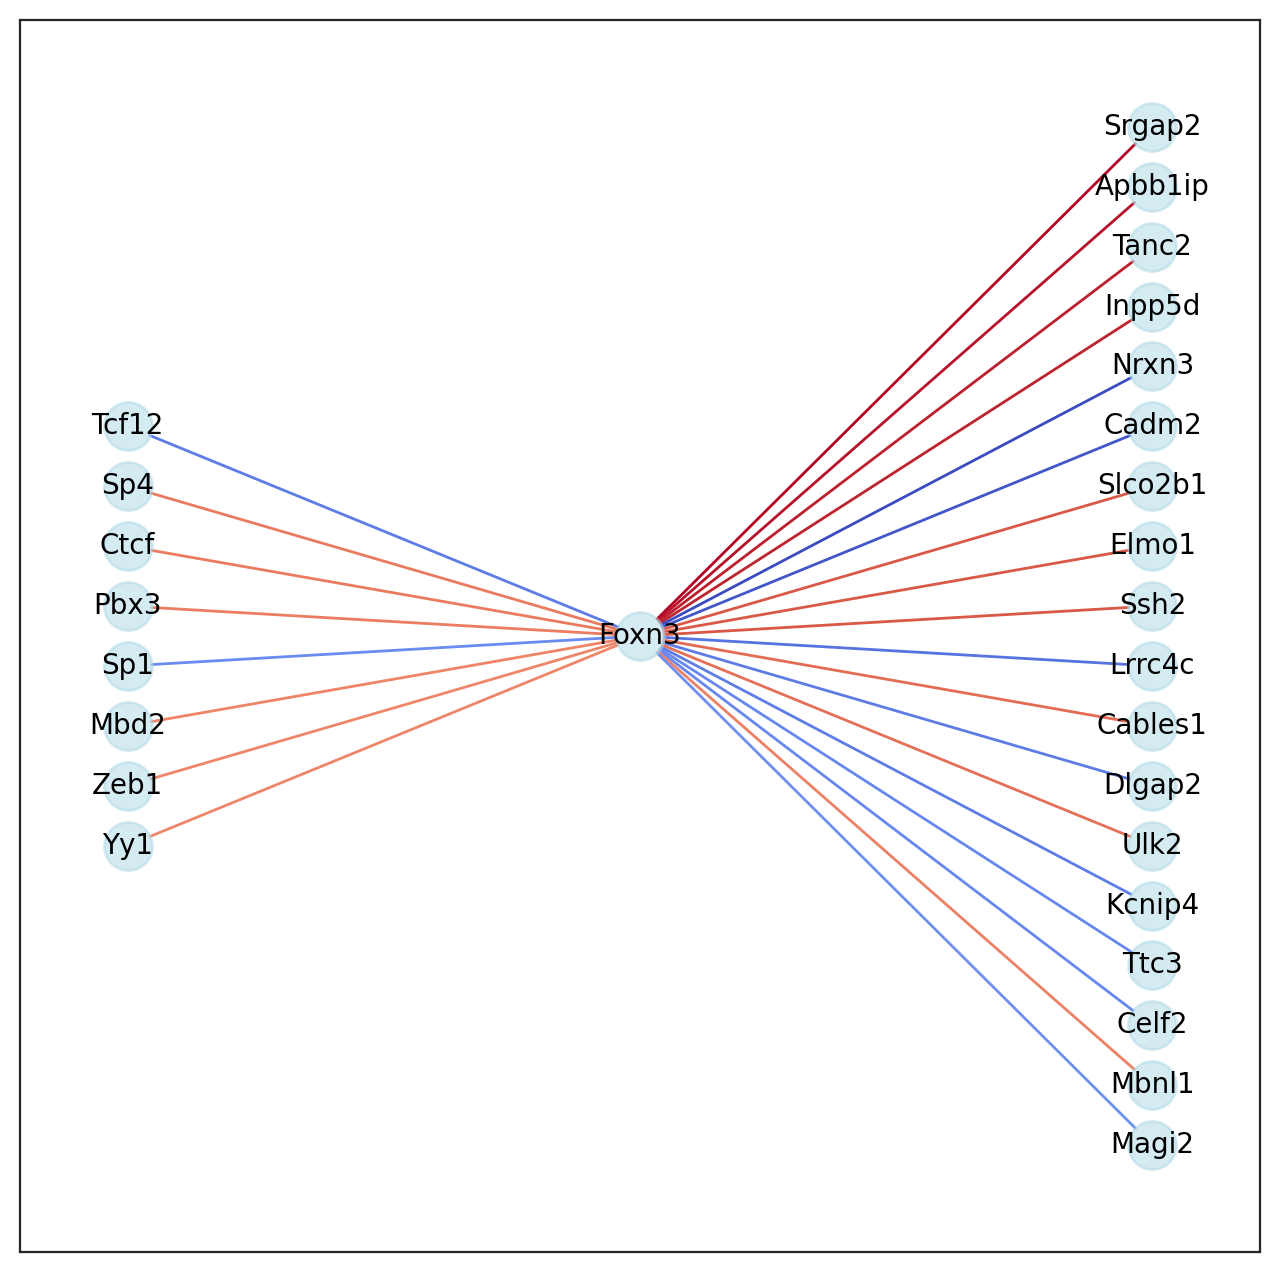

In [359]:
plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(G, pos, node_color="lightblue", alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-", edge_color=edge_weights, edge_cmap=plt.cm.coolwarm)
plt.savefig(f"/cellar/users/aklie/projects/igvf/topic_grn_links/external/igvf_annual_meetings/2023/{genotype}_{tfoi}_multilayered_graph.pdf", transparent=True)

In [360]:

# set alpha value for each edge
for i in range(M):
    edges[i].set_alpha(edge_alphas[i])

pc = mpl.collections.PatchCollection(edges, cmap=cmap)
pc.set_array(edge_colors)

ax = plt.gca()
ax.set_axis_off()
plt.colorbar(pc, ax=ax)
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'set_alpha'

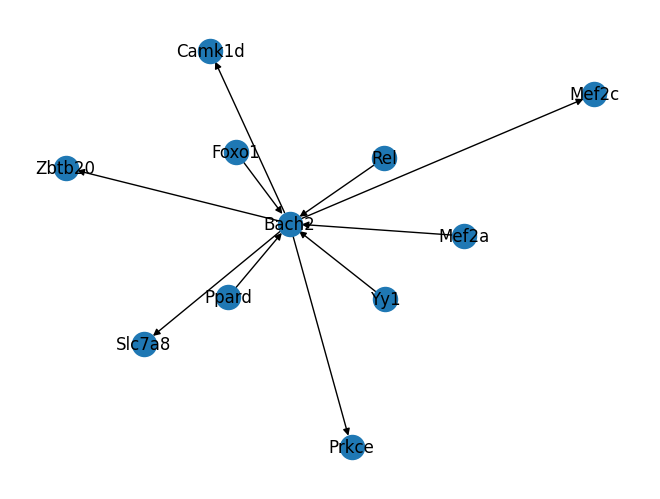

In [107]:
nx.draw(G, with_labels=True)

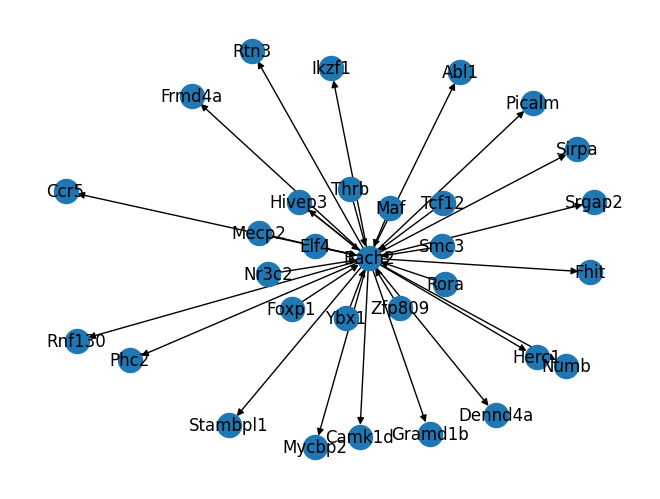

In [100]:
nx.draw(G, with_labels=True)

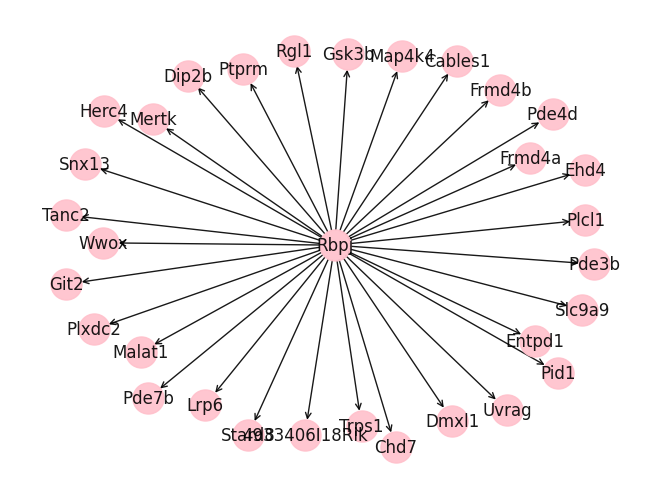

In [66]:
draw_network(plot_links)